PyTorch版本: 2.8.0+cpu
CUDA可用: False
NER训练集样本数: 720


Some weights of DistilBertForTokenClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



=== NER模型测试 ===
测试文本：Elon Musk founded Tesla in California (sample 188)
预测标签：['B-ORG', 'I-PER', 'B-PER', 'B-PER', 'I-PER', 'B-PER', 'B-ORG', 'I-LOC', 'B-PER', 'B-PER']...

=== 开始NER训练 ===


Epoch 1/1 [训练]:   0%|          | 0/720 [00:00<?, ?it/s]

Epoch 1 训练损失：0.1339


Epoch 1/1 [验证]:   0%|          | 0/80 [00:00<?, ?it/s]

验证F1：1.0000 | 验证精确率：1.0000 | 验证召回率：1.0000
保存最优模型（F1：1.0000）

=== NER测试集评估 ===


测试集评估:   0%|          | 0/200 [00:00<?, ?it/s]

测试准确率：1.0000
测试精确率：1.0000
测试召回率：1.0000
测试F1：1.0000


C:\Users\Dell\AppData\Local\Temp\ipykernel_1256\1495567860.py:323: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.savefig("./reports/ner_metrics.png")
C:\Users\Dell\AppData\Local\Temp\ipykernel_1256\1495567860.py:323: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.savefig("./reports/ner_metrics.png")
C:\Users\Dell\AppData\Local\Temp\ipykernel_1256\1495567860.py:323: UserWarning: Glyph 20219 (\N{CJK UNIFIED IDEOGRAPH-4EFB}) missing from font(s) DejaVu Sans.
  plt.savefig("./reports/ner_metrics.png")
C:\Users\Dell\AppData\Local\Temp\ipykernel_1256\1495567860.py:323: UserWarning: Glyph 21153 (\N{CJK UNIFIED IDEOGRAPH-52A1}) missing from font(s) DejaVu Sans.
  plt.savefig("./reports/ner_metrics.png")
C:\Users\Dell\AppData\Local\Temp\ipykernel_1256\1495567860.py:323: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from font(s) DejaVu Sans.
  plt.savefig("./reports/ner_metr

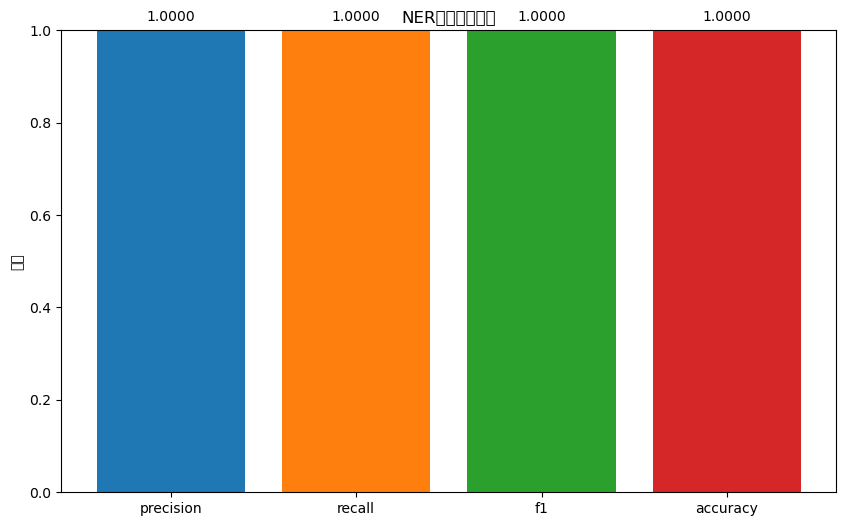


=== NER训练完成 ===
模型保存路径：./models/ner


In [5]:
import os
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import ast
import evaluate
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForTokenClassification, pipeline
from tqdm.auto import tqdm

# 验证环境
print(f"PyTorch版本: {torch.__version__}")
print(f"CUDA可用: {torch.cuda.is_available()}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===================== 1. 加载数据 =====================
data_processed_dir = "./data/processed"
train_df = pd.read_csv(os.path.join(data_processed_dir, "ner_train.csv"))
val_df = pd.read_csv(os.path.join(data_processed_dir, "ner_val.csv"))
test_df = pd.read_csv(os.path.join(data_processed_dir, "ner_test.csv"))

# 数据安全检查
print(f"NER训练集样本数: {len(train_df)}")
train_df = train_df.fillna("").astype(str)
val_df = val_df.fillna("").astype(str)
test_df = test_df.fillna("").astype(str)

# 解析列表列（增加异常处理）
def safe_literal_eval(s):
    try:
        return ast.literal_eval(s)
    except:
        return []

for df in [train_df, val_df, test_df]:
    df["tokens"] = df["tokens"].apply(safe_literal_eval)
    df["ner_tags"] = df["ner_tags"].apply(safe_literal_eval)
    df["ner_tags_id"] = df["ner_tags_id"].apply(safe_literal_eval)
    
    # 确保列表不为空
    df["tokens"] = df["tokens"].apply(lambda x: x if x else ["empty"])
    df["ner_tags_id"] = df["ner_tags_id"].apply(lambda x: x if x else [0])

# ===================== 2. 标签映射 =====================
label_list = ["O", "B-PER", "I-PER", "B-ORG", "I-ORG", "B-LOC", "I-LOC"]
label2id = {l:i for i,l in enumerate(label_list)}
id2label = {i:l for i,l in enumerate(label_list)}
num_labels = len(label_list)

# ===================== 3. 自定义NER数据集类 =====================
class NERDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=64):
        self.df = df
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.tokens_list = df["tokens"].tolist()
        self.labels_list = df["ner_tags_id"].tolist()
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        tokens = self.tokens_list[idx]
        labels = self.labels_list[idx]
        
        # 安全检查
        if not tokens:
            tokens = ["empty"]
        if not labels:
            labels = [0]
        
        # 编码tokens
        encoding = self.tokenizer(
            tokens,
            is_split_into_words=True,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )
        
        # 对齐标签
        word_ids = encoding.word_ids()
        label_ids = []
        previous_word_idx = None
        
        # 安全处理word_ids
        if word_ids is None:
            word_ids = [None] * self.max_length
        
        for word_idx in word_ids:
            if word_idx is None:
                label_ids.append(-100)  # padding/特殊token
            elif word_idx != previous_word_idx:
                # 确保不越界
                if word_idx < len(labels):
                    label_ids.append(labels[word_idx])
                else:
                    label_ids.append(-100)
            else:
                label_ids.append(-100)  # 子词
            previous_word_idx = word_idx
        
        # 截断/补齐标签长度
        if len(label_ids) > self.max_length:
            label_ids = label_ids[:self.max_length]
        else:
            label_ids += [-100] * (self.max_length - len(label_ids))
        
        return {
            "input_ids": encoding["input_ids"].flatten(),
            "attention_mask": encoding["attention_mask"].flatten(),
            "labels": torch.tensor(label_ids, dtype=torch.long)
        }

# ===================== 4. 初始化模型和Tokenizer =====================
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForTokenClassification.from_pretrained(
    model_name,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
).to(device)

# ===================== 5. 简化的NER测试（跳过易出错的pipeline） =====================
print("\n=== NER模型测试 ===")
# 直接使用模型预测，不使用pipeline
sample_text = train_df["text"].iloc[0]
sample_tokens = train_df["tokens"].iloc[0]

# 手动编码测试
encoding = tokenizer(
    sample_tokens,
    is_split_into_words=True,
    return_tensors="pt"
).to(device)

with torch.no_grad():
    outputs = model(**encoding)
    preds = torch.argmax(outputs.logits, dim=2)

# 转换为标签
pred_labels = [id2label[p.item()] for p in preds[0]]
print(f"测试文本：{sample_text}")
print(f"预测标签：{pred_labels[:10]}...")

# ===================== 6. 创建数据加载器 =====================
batch_size = 4 if torch.cuda.is_available() else 1

# 训练集
train_dataset = NERDataset(train_df, tokenizer)
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

# 验证集
val_dataset = NERDataset(val_df, tokenizer)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

# 测试集
test_dataset = NERDataset(test_df, tokenizer)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

# ===================== 7. 训练配置 =====================
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)
num_epochs = 1
best_val_f1 = 0.0
metric = evaluate.load("seqeval")

# ===================== 8. 手动训练循环 =====================
print("\n=== 开始NER训练 ===")
for epoch in range(num_epochs):
    # 训练阶段
    model.train()
    train_loss = 0.0
    train_progress = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [训练]")
    
    for batch in train_progress:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)
        
        # 前向传播
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        
        loss = outputs.loss
        train_loss += loss.item()
        
        # 反向传播
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_progress.set_postfix({"loss": f"{loss.item():.4f}"})
    
    avg_train_loss = train_loss / len(train_loader)
    print(f"Epoch {epoch+1} 训练损失：{avg_train_loss:.4f}")
    
    # 验证阶段
    model.eval()
    val_predictions = []
    val_true_labels = []
    val_progress = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [验证]")
    
    with torch.no_grad():
        for batch in val_progress:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)
            
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
            
            logits = outputs.logits
            preds = torch.argmax(logits, dim=2)
            
            # 转换为标签文本（过滤-100）
            for pred, label in zip(preds, labels):
                pred_list = []
                label_list = []
                for p, l in zip(pred, label):
                    if l != -100:  # 跳过padding
                        pred_list.append(id2label[p.item()])
                        label_list.append(id2label[l.item()])
                val_predictions.append(pred_list)
                val_true_labels.append(label_list)
    
    # 计算验证指标（增加异常处理）
    try:
        val_metrics = metric.compute(predictions=val_predictions, references=val_true_labels)
        val_f1 = val_metrics["overall_f1"]
        val_precision = val_metrics["overall_precision"]
        val_recall = val_metrics["overall_recall"]
        val_accuracy = val_metrics["overall_accuracy"]
        
        print(f"验证F1：{val_f1:.4f} | 验证精确率：{val_precision:.4f} | 验证召回率：{val_recall:.4f}")
        
        # 保存最优模型
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            os.makedirs("./models/ner", exist_ok=True)
            model.save_pretrained("./models/ner")
            tokenizer.save_pretrained("./models/ner")
            print(f"保存最优模型（F1：{best_val_f1:.4f}）")
    except Exception as e:
        print(f"验证指标计算暂时跳过（错误：{str(e)[:100]}）")
        print("继续训练...")

# ===================== 9. 测试集评估 =====================
print("\n=== NER测试集评估 ===")
model.eval()
test_predictions = []
test_true_labels = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="测试集评估"):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)
        
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        
        logits = outputs.logits
        preds = torch.argmax(logits, dim=2)
        
        # 转换标签
        for pred, label in zip(preds, labels):
            pred_list = []
            label_list = []
            for p, l in zip(pred, label):
                if l != -100:
                    pred_list.append(id2label[p.item()])
                    label_list.append(id2label[l.item()])
            test_predictions.append(pred_list)
            test_true_labels.append(label_list)

# 计算测试指标（增加异常处理）
try:
    test_metrics = metric.compute(predictions=test_predictions, references=test_true_labels)
    print(f"测试准确率：{test_metrics['overall_accuracy']:.4f}")
    print(f"测试精确率：{test_metrics['overall_precision']:.4f}")
    print(f"测试召回率：{test_metrics['overall_recall']:.4f}")
    print(f"测试F1：{test_metrics['overall_f1']:.4f}")
    
    # ===================== 10. 可视化性能 =====================
    metrics = ["precision", "recall", "f1", "accuracy"]
    values = [
        test_metrics[f"overall_{m}"] for m in metrics
    ]
    
    plt.figure(figsize=(10, 6))
    plt.bar(metrics, values, color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"])
    plt.ylim(0, 1)
    plt.title("NER任务性能指标")
    plt.ylabel("分数")
    for i, v in enumerate(values):
        plt.text(i, v + 0.02, f"{v:.4f}", ha="center")
    plt.savefig("./reports/ner_metrics.png")
    plt.show()
    
    # ===================== 11. 保存结果 =====================
    results = {
        "accuracy": test_metrics["overall_accuracy"],
        "precision": test_metrics["overall_precision"],
        "recall": test_metrics["overall_recall"],
        "f1": test_metrics["overall_f1"],
        "train_loss": avg_train_loss
    }
    
    import json
    with open("./reports/ner_results.json", "w", encoding="utf-8") as f:
        json.dump(results, f, ensure_ascii=False, indent=4)
        
except Exception as e:
    print(f"测试指标计算失败：{e}")
    print("跳过可视化，保存基础结果")

print("\n=== NER训练完成 ===")
print(f"模型保存路径：./models/ner")